# 📊 Parte 3 – Métricas de Estrés · Análisis Multi-Sesión
**Responsable:** David  
**Fuente de datos:** todos los CSV de la carpeta, generados por `TrackerManager` (Unity)

---
| Métrica | Definición |
|---------|-----------|
| **M₁** | Tasa de `Quick_Jitter_Move` / s → jitter medio de mandos |
| **M₂** | Tasa de `Quick_HMD_Move` / s → frecuencia de escaneo del HMD |
| **stress_index** | (stress_M1 + stress_M2) / 2, normalizado respecto a la sala segura |

> El análisis agrega **todas las sesiones** encontradas y calcula media ± desviación típica por sala.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════
#   CONFIGURACIÓN  ← editar aquí si es necesario
# ════════════════════════════════════════════════
CSV_FOLDER = "../metricas_test"          # carpeta donde están los CSVs (. = misma carpeta)
OUTPUT_FOLDER = "../graphics"
CSV_GLOB   = "*.csv"      # patrón de búsqueda
SAFE_ROOM  = "Room0"      # sala de referencia (baseline)

JITTER_EVENT = "Quick_Jitter_Move"
HMD_EVENT    = "Quick_HMD_Move"
ENTER_PREFIX = "Enter_"

COLS = ["event_name", "session_id", "event_id", "timestamp_ms",
        "pos_x", "pos_y", "pos_z"]

# Paleta visual
BG       = "#0f0f1e"
BG2      = "#1a1a2e"
C_SAFE   = "#4ade80"
C_STRESS = "#f87171"
C_MID    = "#60a5fa"
C_WARN   = "#facc15"

plt.rcParams.update({
    "figure.facecolor": BG2, "axes.facecolor": BG,
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "axes.edgecolor": "#333355", "grid.color": "#333355",
    "grid.linewidth": 0.5,
})

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("✅ Librerías cargadas")
print(f"   Carpeta CSV: {Path(CSV_FOLDER).resolve()}")
print(f"   Sala base:   {SAFE_ROOM}")


✅ Librerías cargadas
   Carpeta CSV: C:\Users\Usuario\Documents\GitHub\Haunted_House_VR\Metricas\metricas_test
   Sala base:   Room0


## 1 · Detección de ficheros CSV

In [2]:
csv_files = sorted(Path(CSV_FOLDER).glob(CSV_GLOB))

# Excluir CSVs de resultados generados por este mismo notebook
EXCLUDE = {"stress_metrics_result.csv", "stress_per_session.csv"}
csv_files = [f for f in csv_files if f.name not in EXCLUDE]

if not csv_files:
    raise FileNotFoundError(
        f"No se encontraron CSVs en '{Path(CSV_FOLDER).resolve()}'. "
        "Revisa CSV_FOLDER o añade ficheros."
    )

print(f"📂 {len(csv_files)} sesión(es) encontrada(s):\n")
for i, f in enumerate(csv_files):
    size_kb = f.stat().st_size / 1024
    print(f"  [{i+1:02d}] {f.name}  ({size_kb:.1f} KB)")


📂 5 sesión(es) encontrada(s):

  [01] telemetry_0.csv  (2.5 KB)
  [02] telemetry_1.csv  (3.5 KB)
  [03] telemetry_2.csv  (5.2 KB)
  [04] telemetry_3.csv  (1.8 KB)
  [05] telemetry_4.csv  (3.3 KB)


## 2 · Carga de todas las sesiones

In [3]:
def load_csv(path):
    df = pd.read_csv(path, header=None, names=COLS, engine="python", on_bad_lines="warn")
    df["timestamp_ms"] = pd.to_numeric(df["timestamp_ms"], errors="coerce")
    df.dropna(subset=["event_name", "timestamp_ms"], inplace=True)
    df["event_name"] = df["event_name"].str.strip()
    df.sort_values("timestamp_ms", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

def assign_rooms(df):
    rooms, current = [], "Unknown"
    for _, row in df.iterrows():
        if row["event_name"].startswith(ENTER_PREFIX):
            current = row["event_name"][len(ENTER_PREFIX):]
        rooms.append(current)
    df = df.copy()
    df["room"] = rooms
    return df

def room_durations(df):
    enters  = df[df["event_name"].str.startswith(ENTER_PREFIX)]
    last_ts = df["timestamp_ms"].iloc[-1]
    durs    = defaultdict(float)
    ts_list   = list(enters["timestamp_ms"])
    room_list = [n[len(ENTER_PREFIX):] for n in enters["event_name"]]
    for i, (ts, room) in enumerate(zip(ts_list, room_list)):
        end = ts_list[i+1] if i+1 < len(ts_list) else last_ts
        durs[room] += (end - ts) / 1000.0
    return dict(durs)

def compute_metrics(df, durations):
    jitter = df[df["event_name"] == JITTER_EVENT].groupby("room").size().rename("jitter_count")
    hmd    = df[df["event_name"] == HMD_EVENT   ].groupby("room").size().rename("hmd_count")
    rooms  = sorted(set(df["room"]) - {"Unknown"})
    m = pd.DataFrame(index=rooms); m.index.name = "room"
    m["duration_s"]   = pd.Series(durations)
    m["jitter_count"] = jitter
    m["hmd_count"]    = hmd
    m.fillna(0, inplace=True)
    safe = m["duration_s"].replace(0, np.nan)
    m["M1_jitter_rate"]   = (m["jitter_count"] / safe).fillna(0)
    m["M2_hmd_scan_rate"] = (m["hmd_count"]    / safe).fillna(0)
    return m

def stress_comparison(metrics, safe_room):
    if safe_room not in metrics.index:
        return metrics
    b1 = metrics.loc[safe_room, "M1_jitter_rate"]
    b2 = metrics.loc[safe_room, "M2_hmd_scan_rate"]
    def safe_ratio(s, b):
        if b > 0: return s / b
        mx = s.max()
        return s / mx if mx > 0 else pd.Series(1.0, index=s.index)
    m = metrics.copy()
    m["stress_M1"]    = safe_ratio(m["M1_jitter_rate"],   b1)
    m["stress_M2"]    = safe_ratio(m["M2_hmd_scan_rate"], b2)
    m["stress_index"] = (m["stress_M1"] + m["stress_M2"]) / 2.0
    return m

# ── Cargar todas las sesiones ──────────────────────────────────────────────
all_sessions = {}   # filename → metrics_df
all_raw      = []   # lista de DataFrames con columna 'file'

for f in csv_files:
    try:
        raw = load_csv(f)
        raw["file"] = f.name
        raw = assign_rooms(raw)
        durs    = room_durations(raw)
        metrics = compute_metrics(raw, durs)
        metrics = stress_comparison(metrics, SAFE_ROOM)
        metrics["file"] = f.name
        all_sessions[f.name] = metrics
        all_raw.append(raw)
        sid = raw["session_id"].iloc[0] if "session_id" in raw.columns else "?"
        dur_total = (raw["timestamp_ms"].max() - raw["timestamp_ms"].min()) / 1000
        print(f"  ✅ {f.name:30s}  sesión={sid[:8]}…  {len(raw):3d} eventos  {dur_total:.1f}s")
    except Exception as e:
        print(f"  ❌ {f.name}: {e}")

print(f"\n  Total sesiones procesadas: {len(all_sessions)}")


  ✅ telemetry_0.csv                 sesión=0c64f0d8…   24 eventos  1442.0s
  ✅ telemetry_1.csv                 sesión=d5e35165…   32 eventos  1309.8s
  ✅ telemetry_2.csv                 sesión=f0e6929d…   45 eventos  1680.4s
  ✅ telemetry_3.csv                 sesión=d4b5c5be…   17 eventos  718.9s
  ✅ telemetry_4.csv                 sesión=10b7de72…   30 eventos  1478.7s

  Total sesiones procesadas: 5


## 3 · Métricas por sesión individual

In [4]:
per_session_rows = []
for fname, m in all_sessions.items():
    tmp = m.reset_index().copy()
    tmp["session"] = fname
    per_session_rows.append(tmp)

per_session = pd.concat(per_session_rows, ignore_index=True)

display_cols = ["session", "room", "duration_s", "jitter_count", "hmd_count",
                "M1_jitter_rate", "M2_hmd_scan_rate", "stress_index"]
display_cols = [c for c in display_cols if c in per_session.columns]

per_session[display_cols].round(4)


,session,room,duration_s,jitter_count,hmd_count,M1_jitter_rate,M2_hmd_scan_rate,stress_index
0,telemetry_0.csv,Pasillo1,88.480,0.0,0.0,0.0000,0.0000,0.0000
1,telemetry_0.csv,Pasillo2,74.940,0.0,0.0,0.0000,0.0000,0.0000
2,telemetry_0.csv,Pasillo3,106.840,1.0,1.0,0.0094,0.0094,1.6555
3,telemetry_0.csv,Room0,606.421,4.0,3.0,0.0066,0.0049,1.0000
4,telemetry_0.csv,Room1,58.340,0.0,0.0,0.0000,0.0000,0.0000
5,telemetry_0.csv,Room2,308.660,3.0,0.0,0.0097,0.0000,0.7368
6,telemetry_0.csv,Room3,198.300,1.0,0.0,0.0050,0.0000,0.3823
7,telemetry_1.csv,Pasillo1,94.159,1.0,2.0,0.0106,0.0212,1.0580
8,telemetry_1.csv,Pasillo2,118.947,2.0,0.0,0.0168,0.0000,0.8834
9,telemetry_1.csv,Pasillo3,391.072,5.0,3.0,0.0128,0.0077,0.8523


## 4 · Agregación entre sesiones

Para cada sala calculamos la **media ± desviación típica** de M₁, M₂ y stress_index
a través de todas las sesiones registradas.


In [5]:
agg_cols = ["M1_jitter_rate", "M2_hmd_scan_rate", "stress_index",
            "duration_s", "jitter_count", "hmd_count"]
agg_cols = [c for c in agg_cols if c in per_session.columns]

agg = per_session.groupby("room")[agg_cols].agg(["mean", "std", "min", "max"])
agg.columns = ["_".join(c) for c in agg.columns]
agg = agg.fillna(0).round(4)

print("═"*90)
print(f"  RESUMEN MULTI-SESIÓN  ({len(all_sessions)} sesiones)")
print("═"*90)
print(f"{'SALA':<15} {'M1 media':>10} {'±std':>8}  {'M2 media':>10} {'±std':>8}  {'stress μ':>10} {'±std':>8}")
print("─"*90)
for room, row in agg.sort_values("stress_index_mean", ascending=False).iterrows():
    si  = row.get("stress_index_mean", 0)
    si_s = row.get("stress_index_std",  0)
    m1  = row.get("M1_jitter_rate_mean", 0)
    m1s = row.get("M1_jitter_rate_std",  0)
    m2  = row.get("M2_hmd_scan_rate_mean", 0)
    m2s = row.get("M2_hmd_scan_rate_std",  0)
    flag = "🔴" if si > 1.5 else ("🟡" if si > 1.0 else "🟢")
    print(f"{flag} {room:<13} {m1:>10.4f} {m1s:>8.4f}  {m2:>10.4f} {m2s:>8.4f}  {si:>10.4f} {si_s:>8.4f}")
print("═"*90)
agg


══════════════════════════════════════════════════════════════════════════════════════════
  RESUMEN MULTI-SESIÓN  (5 sesiones)
══════════════════════════════════════════════════════════════════════════════════════════
SALA              M1 media     ±std    M2 media     ±std    stress μ     ±std
──────────────────────────────────────────────────────────────────────────────────────────
🔴 Pasillo3          0.0157   0.0068      0.0091   0.0039      1.5380   0.4642
🟡 Pasillo2          0.0142   0.0081      0.0035   0.0079      1.0117   0.6790
🟢 Pasillo1          0.0063   0.0040      0.0116   0.0087      0.7557   0.4313
🟢 Room1             0.0105   0.0066      0.0034   0.0048      0.7263   0.4434
🟢 Room0             0.0079   0.0017      0.0021   0.0029      0.7000   0.2739
🟢 Room3             0.0091   0.0028      0.0000   0.0000      0.6067   0.1990
🟢 Room2             0.0088   0.0019      0.0000   0.0000      0.5664   0.1285
══════════════════════════════════════════════════════════════════

,M1_jitter_rate_mean,M1_jitter_rate_std,M1_jitter_rate_min,M1_jitter_rate_max,M2_hmd_scan_rate_mean,M2_hmd_scan_rate_std,M2_hmd_scan_rate_min,M2_hmd_scan_rate_max,stress_index_mean,stress_index_std,...,duration_s_min,duration_s_max,jitter_count_mean,jitter_count_std,jitter_count_min,jitter_count_max,hmd_count_mean,hmd_count_std,hmd_count_min,hmd_count_max
room,,,,,,,,,,,,,,,,,,,,,
Pasillo1,0.0063,0.0040,0.0000,0.0106,0.0116,0.0087,0.0000,0.0212,0.7557,0.4313,...,88.480,279.666,1.00,0.7071,0.0,2.0,1.8,1.4832,0.0,4.0
Pasillo2,0.0142,0.0081,0.0000,0.0200,0.0035,0.0079,0.0000,0.0177,1.0117,0.6790,...,60.052,118.947,1.40,0.8944,0.0,2.0,0.4,0.8944,0.0,2.0
Pasillo3,0.0157,0.0068,0.0094,0.0251,0.0091,0.0039,0.0051,0.0143,1.5380,0.4642,...,106.840,391.072,4.75,2.6300,1.0,7.0,2.5,1.2910,1.0,4.0
Room0,0.0079,0.0017,0.0057,0.0095,0.0021,0.0029,0.0000,0.0057,0.7000,0.2739,...,105.080,606.421,1.80,1.3038,1.0,4.0,0.8,1.3038,0.0,3.0
Room1,0.0105,0.0066,0.0000,0.0152,0.0034,0.0048,0.0000,0.0101,0.7263,0.4434,...,58.340,198.414,1.60,1.1402,0.0,3.0,0.6,0.8944,0.0,2.0
Room2,0.0088,0.0019,0.0066,0.0104,0.0000,0.0000,0.0000,0.0000,0.5664,0.1285,...,289.378,308.660,2.60,0.5477,2.0,3.0,0.0,0.0000,0.0,0.0
Room3,0.0091,0.0028,0.0050,0.0111,0.0000,0.0000,0.0000,0.0000,0.6067,0.1990,...,179.454,290.959,2.00,0.8165,1.0,3.0,0.0,0.0000,0.0,0.0


## 5 · M₁ y M₂ medias por sala con barras de error

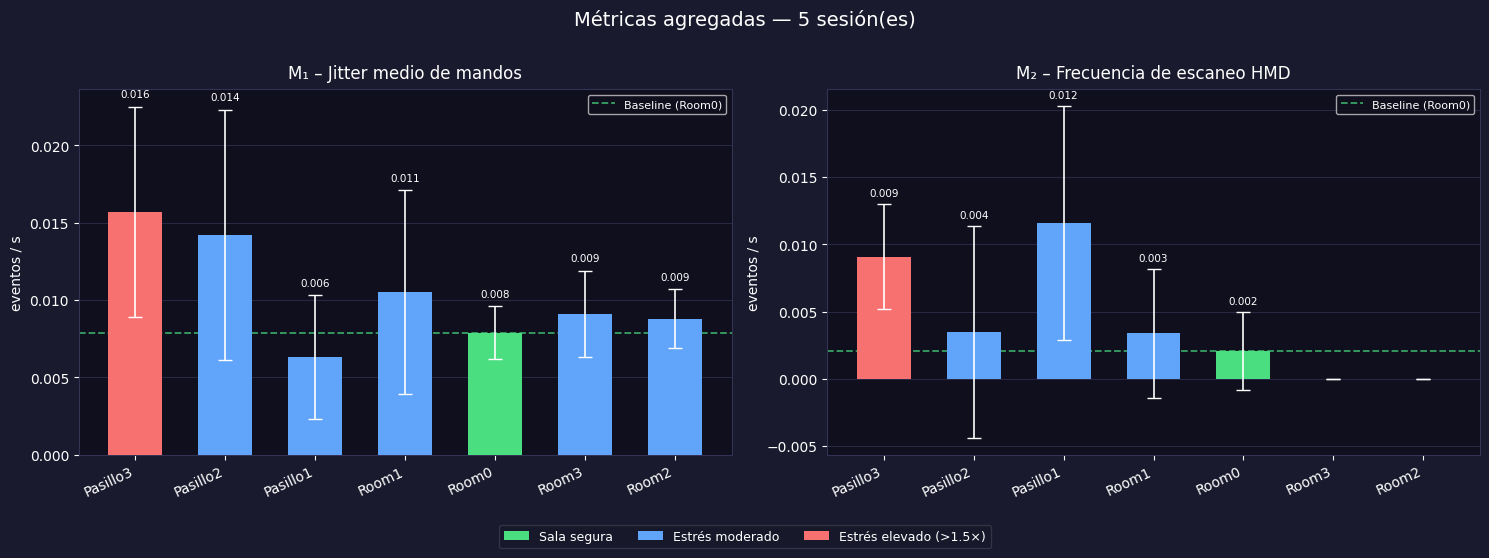

💾 Guardado: stress_barras_media.png


In [6]:
rooms_sorted = agg.sort_values("stress_index_mean", ascending=False).index.tolist()
x = np.arange(len(rooms_sorted))
w = 0.35

def bar_color(room, si):
    if room == SAFE_ROOM: return C_SAFE
    if si > 1.5:          return C_STRESS
    return C_MID

colors = [bar_color(r, agg.loc[r, "stress_index_mean"]) for r in rooms_sorted]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=BG2)

for ax, metric, label, title in [
    (axes[0], "M1_jitter_rate",   "eventos / s", "M₁ – Jitter medio de mandos"),
    (axes[1], "M2_hmd_scan_rate", "eventos / s", "M₂ – Frecuencia de escaneo HMD"),
]:
    means = [agg.loc[r, f"{metric}_mean"] for r in rooms_sorted]
    stds  = [agg.loc[r, f"{metric}_std"]  for r in rooms_sorted]
    bars  = ax.bar(x, means, width=0.6, color=colors, edgecolor="none",
                   yerr=stds, capsize=5, error_kw={"ecolor": "white", "elinewidth": 1.2},
                   zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(rooms_sorted, rotation=25, ha="right")
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_ylabel(label)
    ax.grid(axis="y", zorder=0)

    # Línea baseline
    if SAFE_ROOM in agg.index:
        ax.axhline(agg.loc[SAFE_ROOM, f"{metric}_mean"], color=C_SAFE,
                   ls="--", lw=1.3, alpha=0.7, label=f"Baseline ({SAFE_ROOM})")
        ax.legend(fontsize=8)

    for bar, m, s in zip(bars, means, stds):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    m + s + ax.get_ylim()[1]*0.02,
                    f"{m:.3f}", ha="center", va="bottom", color="white", fontsize=7.5)

fig.suptitle(f"Métricas agregadas — {len(all_sessions)} sesión(es)", 
             fontsize=14, color="white", y=1.01)

legend_elements = [
    mpatches.Patch(facecolor=C_SAFE,   label="Sala segura"),
    mpatches.Patch(facecolor=C_MID,    label="Estrés moderado"),
    mpatches.Patch(facecolor=C_STRESS, label="Estrés elevado (>1.5×)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fancybox=True, framealpha=0.15, labelcolor="white",
           fontsize=9, bbox_to_anchor=(0.5, -0.08))


plt.tight_layout()
output_path = os.path.join(OUTPUT_FOLDER, "stress_barras_media.png")

plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor=BG2)

plt.show()
print("💾 Guardado: stress_barras_media.png")


## 6 · Índice de estrés por sala y sesión (boxplot)

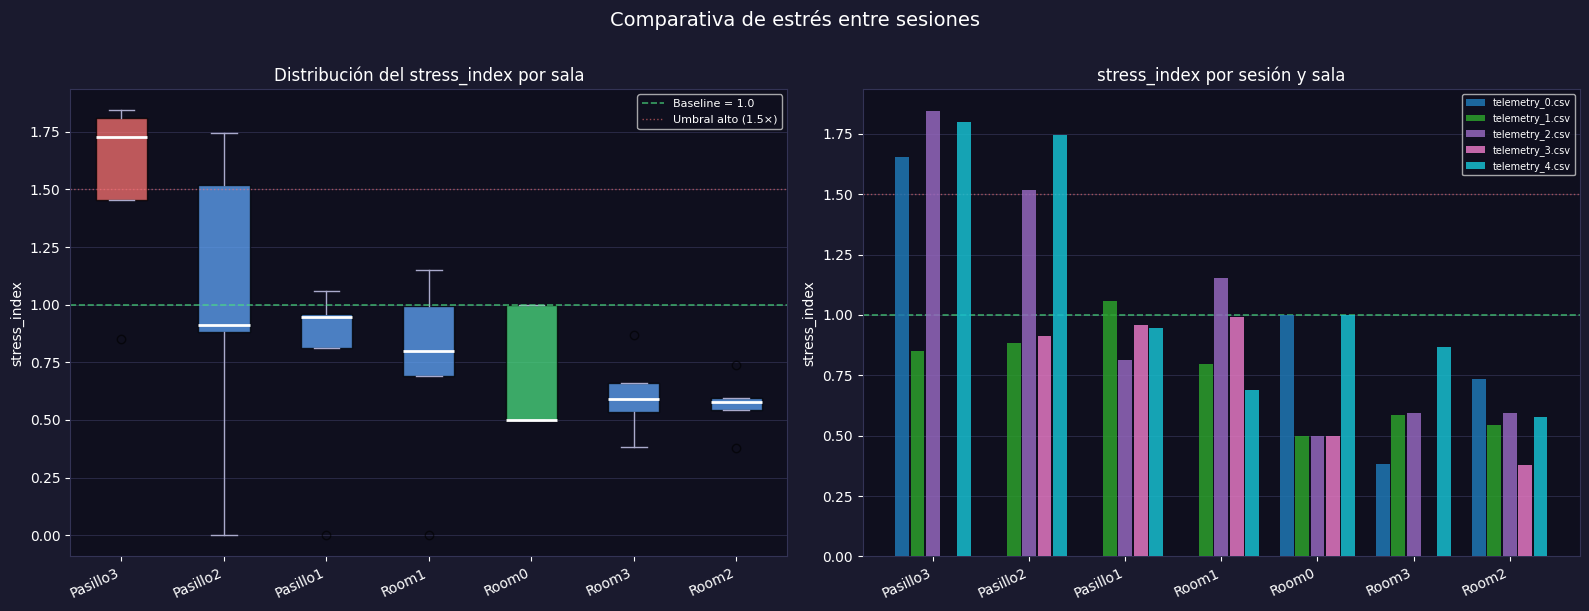

💾 Guardado: ../graphics\stress_boxplot_sesiones.png


In [7]:
if "stress_index" not in per_session.columns:
    print("⚠️ stress_index no disponible (necesita ≥1 sesión con sala segura)")
else:
    rooms_order = (per_session.groupby("room")["stress_index"]
                   .mean().sort_values(ascending=False).index.tolist())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG2)

    # ── Boxplot por sala ──────────────────────────────────────────────────
    ax = axes[0]
    data_by_room = [per_session[per_session["room"] == r]["stress_index"].values
                    for r in rooms_order]
    bp = ax.boxplot(data_by_room, labels=rooms_order, patch_artist=True,
                    medianprops={"color": "white", "linewidth": 2},
                    whiskerprops={"color": "#aaaacc"},
                    capprops={"color": "#aaaacc"},
                    flierprops={"marker": "o", "color": "#f87171", "alpha": 0.6})
    for patch, room in zip(bp["boxes"], rooms_order):
        si = per_session[per_session["room"] == room]["stress_index"].mean()
        patch.set_facecolor(bar_color(room, si))
        patch.set_alpha(0.75)

    ax.axhline(1.0, color=C_SAFE,   ls="--", lw=1.2, alpha=0.7, label="Baseline = 1.0")
    ax.axhline(1.5, color=C_STRESS, ls=":",  lw=1.0, alpha=0.6, label="Umbral alto (1.5×)")
    ax.set_title("Distribución del stress_index por sala", fontsize=12)
    ax.set_ylabel("stress_index")
    ax.set_xticklabels(rooms_order, rotation=25, ha="right")
    ax.legend(fontsize=8)
    ax.grid(axis="y", zorder=0)

    # ── Barras stress_index por sesión ────────────────────────────────────
    ax2 = axes[1]
    sessions_list = list(all_sessions.keys())
    n_sessions = len(sessions_list)
    n_rooms    = len(rooms_order)
    bar_w = 0.8 / n_sessions if n_sessions > 0 else 0.4
    session_colors = plt.cm.tab10(np.linspace(0, 0.9, n_sessions))

    for si_idx, (fname, color) in enumerate(zip(sessions_list, session_colors)):
        m = all_sessions[fname]
        if "stress_index" not in m.columns:
            continue
        vals = [m.loc[r, "stress_index"] if r in m.index else 0 for r in rooms_order]
        offsets = np.arange(n_rooms) + si_idx * bar_w - (n_sessions - 1) * bar_w / 2
        ax2.bar(offsets, vals, width=bar_w * 0.9, color=color,
                label=fname, edgecolor="none", alpha=0.85, zorder=3)

    ax2.set_xticks(np.arange(n_rooms))
    ax2.set_xticklabels(rooms_order, rotation=25, ha="right")
    ax2.axhline(1.0, color=C_SAFE,   ls="--", lw=1.2, alpha=0.7)
    ax2.axhline(1.5, color=C_STRESS, ls=":",  lw=1.0, alpha=0.6)
    ax2.set_title("stress_index por sesión y sala", fontsize=12)
    ax2.set_ylabel("stress_index")
    ax2.legend(fontsize=7, loc="upper right")
    ax2.grid(axis="y", zorder=0)

    fig.suptitle("Comparativa de estrés entre sesiones", fontsize=14, color="white", y=1.01)
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_FOLDER, "stress_boxplot_sesiones.png")

    plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor=BG2)
    plt.show()
    print(f"💾 Guardado: {output_path}")


## 7 · Heatmap stress_index — sala × sesión

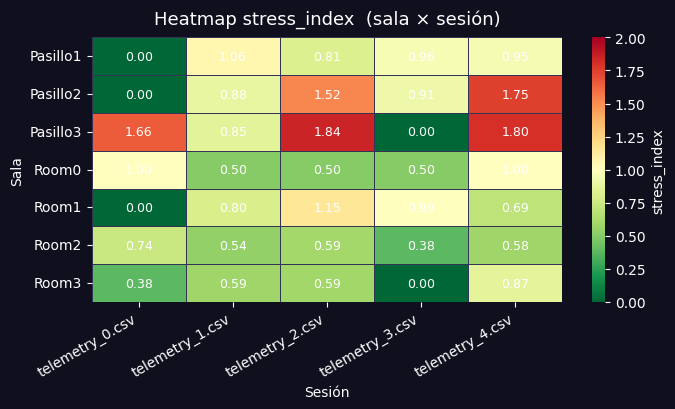

💾 Guardado: ../graphics\stress_heatmap_sesiones.png


In [8]:
if "stress_index" in per_session.columns:
    pivot = per_session.pivot_table(values="stress_index",
                                    index="room", columns="session",
                                    aggfunc="mean").fillna(0)

    fig_h = max(4, len(pivot.index) * 0.6)
    fig_w = max(7, len(pivot.columns) * 1.4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor=BG)
    ax.set_facecolor(BG)

    sns.heatmap(pivot, annot=True, fmt=".2f", ax=ax,
                cmap="RdYlGn_r", vmin=0, vmax=max(2, pivot.values.max()),
                linewidths=0.4, linecolor="#333355",
                cbar_kws={"label": "stress_index"},
                annot_kws={"size": 9, "color": "white"})

    ax.set_title("Heatmap stress_index  (sala × sesión)", color="white", fontsize=13, pad=10)
    ax.set_xlabel("Sesión", color="white")
    ax.set_ylabel("Sala",   color="white")
    plt.setp(ax.get_xticklabels(), color="white", rotation=30, ha="right")
    plt.setp(ax.get_yticklabels(), color="white")
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors="white")
    cbar.set_label("stress_index", color="white")

    plt.tight_layout()
    output_path = os.path.join(OUTPUT_FOLDER, "stress_heatmap_sesiones.png")
    plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"💾 Guardado: {output_path}")


## 8 · Línea de tiempo de todas las sesiones

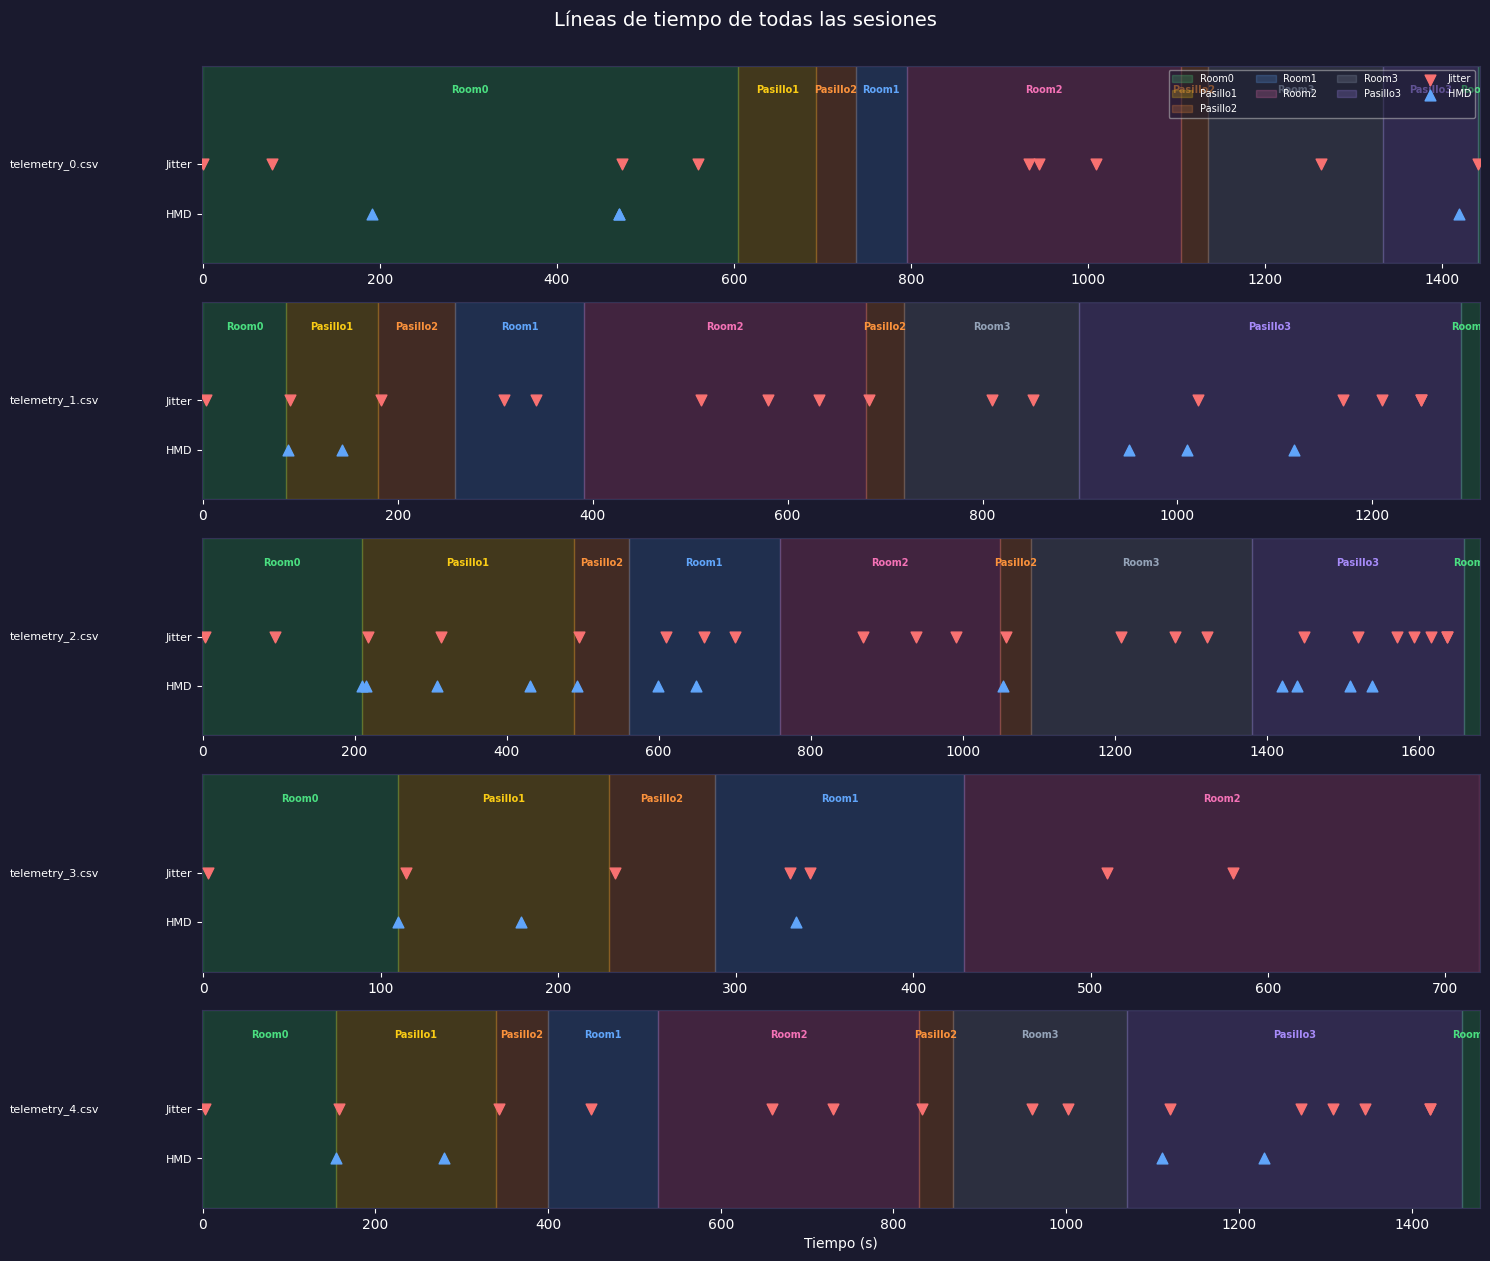

💾 Guardado: ../graphics\timeline_multi.png


In [9]:
ROOM_COLORS = {
    "Room0":    "#4ade80", "Room1": "#60a5fa", "Room2": "#f472b6",
    "Pasillo1": "#facc15", "Pasillo2": "#fb923c", "Pasillo3": "#a78bfa",
}
get_c = lambda r: ROOM_COLORS.get(r, "#94a3b8")

combined = pd.concat(all_raw, ignore_index=True)
session_names = combined["file"].unique()
n = len(session_names)

fig, axes = plt.subplots(n, 1, figsize=(15, 2.5 * n), facecolor=BG2,
                         sharex=False, squeeze=False)

for idx, (fname, ax_row) in enumerate(zip(session_names, axes)):
    ax = ax_row[0]
    ax.set_facecolor(BG)
    sdf = combined[combined["file"] == fname].copy()
    sdf["t_s"] = (sdf["timestamp_ms"] - sdf["timestamp_ms"].min()) / 1000.0
    last_t = sdf["t_s"].max()

    enters = sdf[sdf["event_name"].str.startswith(ENTER_PREFIX)]
    ts_list   = list(enters["t_s"])
    room_list = [n_[len(ENTER_PREFIX):] for n_ in enters["event_name"]]

    seen_rooms = set()
    for i, (ts, room) in enumerate(zip(ts_list, room_list)):
        end = ts_list[i+1] if i+1 < len(ts_list) else last_t
        label = room if room not in seen_rooms else "_nolegend_"
        seen_rooms.add(room)
        ax.axvspan(ts, end, alpha=0.22, color=get_c(room), zorder=0, label=label)
        mid = (ts + end) / 2
        ax.text(mid, 1.75, room, ha="center", va="center",
                color=get_c(room), fontsize=7, fontweight="bold", clip_on=True)

    jit = sdf[sdf["event_name"] == JITTER_EVENT]
    hmd = sdf[sdf["event_name"] == HMD_EVENT]
    ax.scatter(jit["t_s"], [1.0]*len(jit), color=C_STRESS, s=60, zorder=5,
               marker="v", label="Jitter")
    ax.scatter(hmd["t_s"], [0.5]*len(hmd), color=C_MID,    s=60, zorder=5,
               marker="^", label="HMD")

    ax.set_xlim(-0.5, last_t + 0.5)
    ax.set_ylim(0, 2)
    ax.set_yticks([0.5, 1.0]); ax.set_yticklabels(["HMD", "Jitter"], fontsize=8)
    ax.set_ylabel(fname, fontsize=8, color="white", rotation=0, labelpad=80, va="center")
    ax.tick_params(colors="white")
    for sp in ax.spines.values(): sp.set_edgecolor("#333355")
    if idx == 0:
        ax.legend(loc="upper right", facecolor=BG2, labelcolor="white", fontsize=7,
                  ncol=4, framealpha=0.5)
    if idx == n - 1:
        ax.set_xlabel("Tiempo (s)", color="white")

fig.suptitle("Líneas de tiempo de todas las sesiones", fontsize=14,
             color="white", y=1.005)
plt.tight_layout()
output_path = os.path.join(OUTPUT_FOLDER, "timeline_multi.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor=BG2)
plt.show()
print(f"💾 Guardado: {output_path}")


## 9 · Exportar resultados a CSV

In [10]:
output_dir = Path(OUTPUT_FOLDER)

# Tabla agregada (una fila por sala)
agg.to_csv(output_dir / "stress_metrics_result.csv", index=False)
print("✅ stress_metrics_result.csv  — métricas agregadas por sala")

# Tabla detallada (una fila por sala × sesión)
per_session.round(6).to_csv(output_dir / "stress_per_session.csv", index=False)
print("✅ stress_per_session.csv     — métricas por sala y sesión")


✅ stress_metrics_result.csv  — métricas agregadas por sala
✅ stress_per_session.csv     — métricas por sala y sesión


## 10 · Conclusiones automáticas

In [11]:
W = 62
print("═"*W)
print(f"  RESUMEN MULTI-SESIÓN  ({len(all_sessions)} sesión(es))")
print("═"*W)

if "stress_index" in per_session.columns and "stress_index_mean" in agg.columns:
    ranked = agg["stress_index_mean"].sort_values(ascending=False)

    print(f"\n  Sala de referencia (baseline): {SAFE_ROOM}")
    print(f"  Sala con mayor estrés medio:   {ranked.index[0]}  ({ranked.iloc[0]:.3f}×)")

    stressed = agg[
        (agg.index != SAFE_ROOM) & (agg["stress_index_mean"] > 1.5)
    ]
    moderate = agg[
        (agg.index != SAFE_ROOM) &
        (agg["stress_index_mean"] > 1.0) &
        (agg["stress_index_mean"] <= 1.5)
    ]

    if not stressed.empty:
        print(f"\nSalas con estrés ELEVADO medio (>1.5×):")
        for r, row in stressed.iterrows():
            cv = row["stress_index_std"] / row["stress_index_mean"] * 100 if row["stress_index_mean"] else 0
            print(f"      {r:<14} {row['stress_index_mean']:.3f}× ± {row['stress_index_std']:.3f}  "
                  f"(CV={cv:.0f}%)")
    else:
        print("\nNinguna sala supera el umbral de estrés elevado (1.5×) de media.")

    if not moderate.empty:
        print(f"\nSalas con estrés MODERADO medio (1.0–1.5×):")
        for r, row in moderate.iterrows():
            print(f"      {r:<14} {row['stress_index_mean']:.3f}×")

    # Variabilidad entre usuarios
    high_var = agg[agg["stress_index_std"] > 0.3]
    if not high_var.empty:
        print(f"\nAlta variabilidad entre sesiones (std>0.3) en:")
        for r, row in high_var.iterrows():
            print(f"      {r:<14} std={row['stress_index_std']:.3f}")

    # Métrica dominante (excluye sala segura)
    rest = per_session[per_session["room"] != SAFE_ROOM]
    if not rest.empty and "stress_M1" in rest.columns:
        avg1 = rest["stress_M1"].mean()
        avg2 = rest["stress_M2"].mean()
        dom  = "mandos / jitter (M₁)" if avg1 > avg2 else "HMD / escaneo visual (M₂)"
        print(f"\nIndicador dominante de estrés: {dom}")
        print(f"      M₁ medio global: {avg1:.3f}×")
        print(f"      M₂ medio global: {avg2:.3f}×")

print("\n" + "═"*W)


══════════════════════════════════════════════════════════════
  RESUMEN MULTI-SESIÓN  (5 sesión(es))
══════════════════════════════════════════════════════════════

  Sala de referencia (baseline): Room0
  Sala con mayor estrés medio:   Pasillo3  (1.538×)

Salas con estrés ELEVADO medio (>1.5×):
      Pasillo3       1.538× ± 0.464  (CV=30%)

Salas con estrés MODERADO medio (1.0–1.5×):
      Pasillo2       1.012×

Alta variabilidad entre sesiones (std>0.3) en:
      Pasillo1       std=0.431
      Pasillo2       std=0.679
      Pasillo3       std=0.464
      Room1          std=0.443

Indicador dominante de estrés: mandos / jitter (M₁)
      M₁ medio global: 1.359×
      M₂ medio global: 0.347×

══════════════════════════════════════════════════════════════
